In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df=pd.read_csv('economic_index.csv')

In [75]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [76]:
df.shape

(24, 6)

In [77]:
## there is unnecessory columns we need to drop them 
df.drop(columns=["Unnamed: 0","year","month"],inplace=True)

In [78]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [79]:
## checking for null values
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

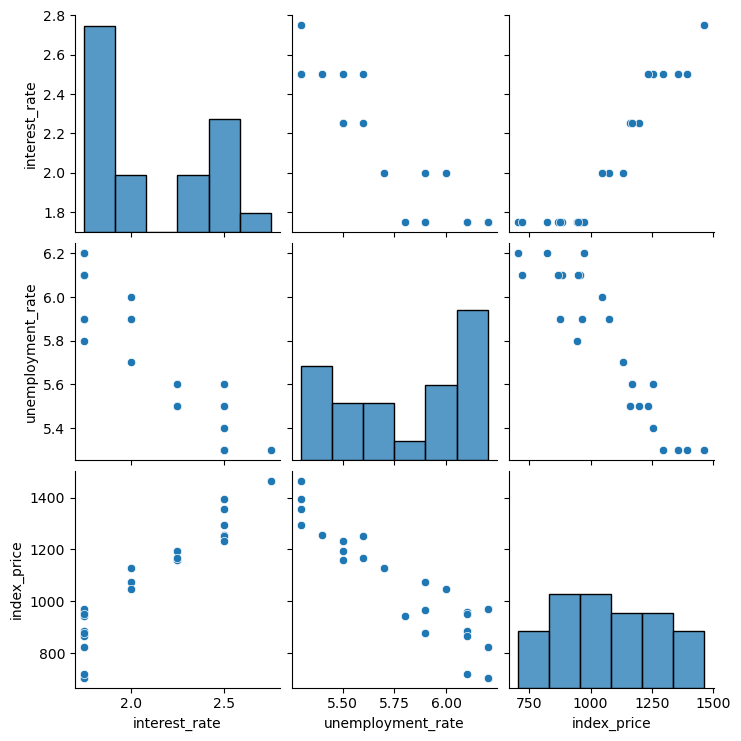

In [80]:
##Visualization
sns.pairplot(df)

In [81]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [82]:
## get my dependent and independent feature using i loc function
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [83]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [84]:
x.shape

(24, 2)

In [85]:
y.shape

(24,)

In [86]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

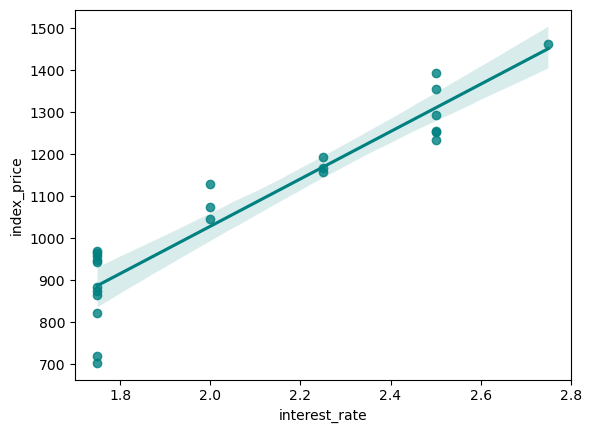

In [87]:
## Visualization using regression plot
sns.regplot(x=df['interest_rate'],y=df['index_price'],color='teal')
## here we can see that here is x is increasing and the same time y is increasing positive correlation

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

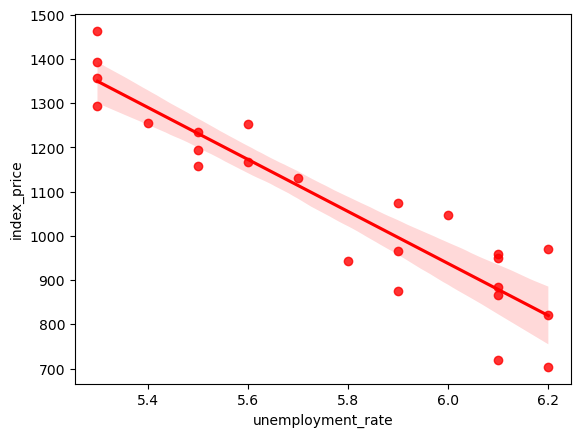

In [88]:
sns.regplot(x=df['unemployment_rate'],y=df['index_price'],color='red')
##here we can see that here is x is increasing at that time y is decreasing here is negative correlateion

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

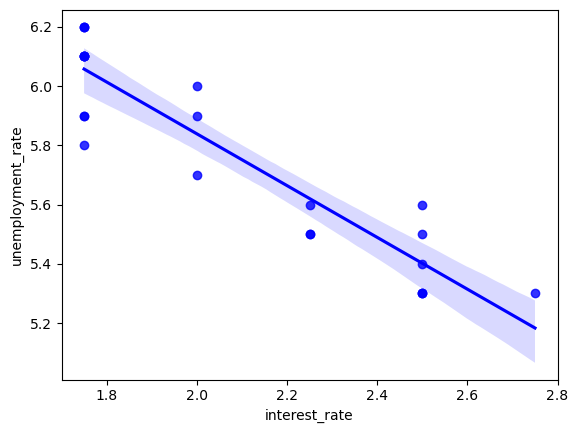

In [89]:
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'],color='blue')

In [90]:
## scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [93]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()


In [94]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
## Cross Validation
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(model,x_train,y_train,scoring='neg_mean_squared_error',cv=3)


In [100]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [103]:
print("The average cross validation score is :",np.average(validation_score))
## this is my averge cross validation score

The average cross validation score is : -5914.828180162392


In [104]:
#Prediction
y_pred=model.predict(x_test)

In [105]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [106]:
#Errors
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error
MSE=mean_squared_error(y_test,y_pred)
MAE=mean_absolute_error(y_test,y_pred)
RMSE=root_mean_squared_error(y_test,y_pred)
print("Root Mean suqare error:",MSE)
print("Mean Absolute Error :",MAE)
print("Root Mean Square Error :",RMSE)

Root Mean suqare error: 5793.762887712589
Mean Absolute Error : 59.9357815232356
Root Mean Square Error : 76.11677139574819


In [107]:
## r2 square
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("The R2 score is :",score)

The R2 score is : 0.827897809145714


In [108]:
## Adjusted r2 score
Adjusted_r2_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

In [109]:
print("The Adjusted R2 score is :",Adjusted_r2_score)

The Adjusted R2 score is : 0.7131630152428566


## Assumptions

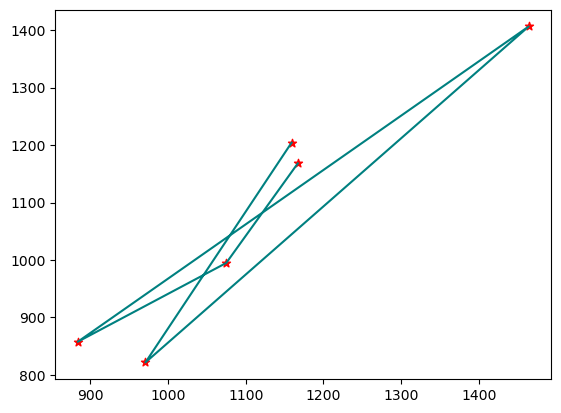

In [118]:
plt.plot(y_test,y_pred,color='teal')
plt.scatter(y_test,y_pred,marker='*',color='red')
##there is linear relationship between predicted data points and actual data points

In [119]:
## getting errors
residual=y_test-y_pred
print(residual)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


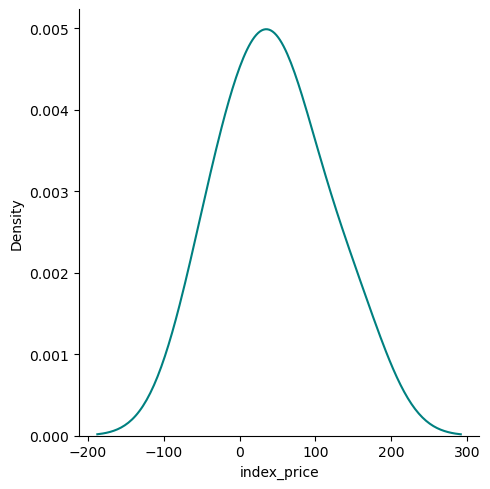

In [121]:
## Plotting this residuals
sns.displot(residual,kind='kde',color='teal')

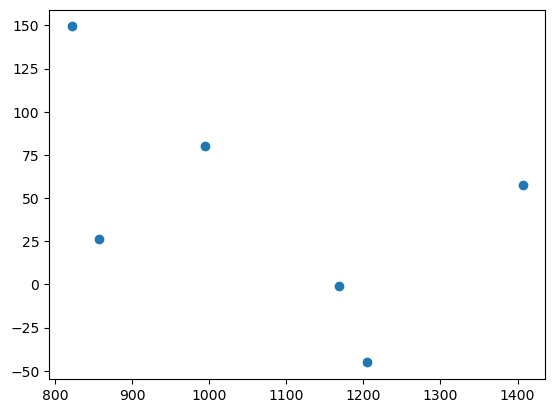

In [127]:
## Scatterplot with respect to prediction and residuals
plt.scatter(y_pred,residual)


In [128]:
#   Linear Regression with OLS
import statsmodels.api as sm
model_ols=sm.OLS(y_train,x_train).fit()

In [131]:
prediction=model_ols.predict(x_test)

In [132]:
print(prediction)

[ 150.78325954 -231.79392541  353.06855924 -195.73554836  -58.53452146
  114.72488249]


In [133]:
print(model_ols.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Fri, 25 Sep 2026   Prob (F-statistic):                       0.754
Time:                        23:44:28   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [134]:
model.coef_

array([  88.27275507, -116.25716066])